In [1]:
from import_pkgs import *
from data_utils import *

# Taking Thailand as an illustrative example

In [13]:
pcd_meteo_info = pd.read_csv(TH_METEO + "PCD_stations/Thailand_PCD_station_info.csv")
pcd_meteo_info = pd.read_csv(TH_METEO + "PCD_stations/Thailand_PCD_station_info.csv")

def pcd_meteo_coord(sid):
    row = pcd_meteo_info.loc[pcd_meteo_info["stationID"] == sid,
                              ["latitude_north", "longitude_east"]]
    return (row["latitude_north"].values[0], row["longitude_east"].values[0]) if len(row) else None

def pcd_meteo_coord(sid):
    row = pcd_meteo_info.loc[pcd_meteo_info["stationID"] == sid,
                              ["latitude_north", "longitude_east"]]
    return (row["latitude_north"].values[0], row["longitude_east"].values[0]) if len(row) else None

pcd_aq_info = pd.read_csv(TH_CONC + "PCD_stations/Thailand_PCD_station_info_conc.csv")
pcd_aq_info = pd.read_csv(TH_CONC + "PCD_stations/Thailand_PCD_station_info_conc.csv")

def pcd_aq_coord(sid):
    row = pcd_aq_info.loc[pcd_aq_info["stationID"] == sid,
                           ["latitude_north", "longitude_east"]]
    return (row["latitude_north"].values[0], row["longitude_east"].values[0]) if len(row) else None

def pcd_aq_coord(sid):
    row = pcd_aq_info.loc[pcd_aq_info["stationID"] == sid,
                           ["latitude_north", "longitude_east"]]
    return (row["latitude_north"].values[0], row["longitude_east"].values[0]) if len(row) else None

In [14]:
def get_urban_ids(meta_csv, id_col, gub_gdf):
    meta = pd.read_csv(meta_csv)
    gdf = gpd.GeoDataFrame(
        meta,
        geometry=gpd.points_from_xy(meta["longitude_east"], meta["latitude_north"]),
        crs="EPSG:4326"
    )
    urban = gpd.sjoin(gdf, gub_gdf, how="inner", predicate="intersects")
    return set(urban[id_col])

TH_METEO_URBAN_IDS = {
    "PCD": get_urban_ids(TH_METEO + "PCD_stations/Thailand_PCD_station_info.csv", "stationID", gub_th),
    "PCD": get_urban_ids(TH_METEO + "PCD_stations/Thailand_PCD_station_info.csv", "stationID", gub_th),
}

In [15]:
DATE_START, DATE_END = "2024-02-01", "2024-03-31"
TH_METEO_OBS = {
    ("PCD", "TSA"):  TH_METEO + "pcd_temp_daily.csv",
    ("PCD", "TSA"):  TH_METEO + "pcd_temp_daily.csv",
    ("PCD", "RH2M"): TH_METEO + "pcd_rh_daily.csv",
    ("PCD", "RH2M"): TH_METEO + "pcd_rh_daily.csv",
    ("PCD", "wind_speed"): TH_METEO + "pcd_ws_daily.csv",
    ("PCD", "wind_speed"): TH_METEO + "pcd_ws_daily.csv",
    ("PCD", "wind_direction"): TH_METEO + "pcd_wd_daily.csv",
    ("PCD", "wind_direction"): TH_METEO + "pcd_wd_daily.csv",
}
OBS_PREFIX = {
    "TSA":  {"PCD": "Temp_", "PCD": "TEMP_"},
    "RH2M": {"PCD": "RH_",   "PCD": "RH_"},
    "wind_speed": {"PCD": "WS_",   "PCD": "WS_"},
    "wind_direction": {"PCD": "WD_",   "PCD": "WD_"},
}
MOD_VAR_TH = {
    "TSA":  "TSA",
    "RH2M": "RH2M",
    "wind_speed": "wind_speed",
    "wind_direction": "wind_direction"
}

___

## Fig 2a: Time series plot across ground sites

___

### Temperature

In [16]:
station_type='PCD'
var='TSA'
obs_csv = TH_METEO_OBS[(station_type, var)]
obs_df = pd.read_csv(obs_csv, parse_dates=["date"])
mask = (obs_df["date"] >= DATE_START) & (obs_df["date"] <= DATE_END)
obs_sub = obs_df.loc[mask].copy()
prefix  = OBS_PREFIX[var][station_type]
mod_var = MOD_VAR_TH[var]
offset  = -273.15 if var == "TSA" else 0.0
site_cols = [c for c in obs_sub.columns if c.startswith(prefix)]
site_cols = [c for c in site_cols if c.replace(prefix, "") in TH_METEO_URBAN_IDS[station_type]]

PCD_temp_avgs={
    'obs':[],
    'ctrl':[],
    'test':[]
}
for col in site_cols:
    site_id  = col.replace(prefix, "")
    base     = TH_METEO + f"{station_type}_stations/{site_id}_"
    test_csv = base + "urban_mod_TRHQPRCPWIND_daily.csv"
    ctrl_csv = base + "ctrl_mod_TRHQPRCPWIND_daily.csv"

    obs_ts = obs_sub[["date", col]].rename(columns={col: "obs"})
    obs_ts["obs"] = pd.to_numeric(obs_ts["obs"], errors="coerce").replace(0.0, np.nan)
    test_df = pd.read_csv(test_csv)
    test_df["Time_UTC"] = pd.to_datetime(test_df["Time_UTC"]).dt.floor("D")
    test_ts = test_df[["Time_UTC", mod_var]].rename(
        columns={"Time_UTC": "date", mod_var: "test"})
    test_ts["test"] = test_ts["test"] + offset
    ctrl_df = pd.read_csv(ctrl_csv)
    ctrl_df["Time_UTC"] = pd.to_datetime(ctrl_df["Time_UTC"]).dt.floor("D")
    ctrl_ts = ctrl_df[["Time_UTC", mod_var]].rename(
        columns={"Time_UTC": "date", mod_var: "ctrl"})
    ctrl_ts["ctrl"] = ctrl_ts["ctrl"] + offset
    df_cmp = pd.concat([
        obs_ts.set_index("date"),
        test_ts.set_index("date"),
        ctrl_ts.set_index("date"),
    ], axis=1, join="inner").reset_index().dropna(how="all")
    PCD_temp_avgs['obs'].append(df_cmp['obs'].values)
    PCD_temp_avgs['ctrl'].append(df_cmp['ctrl'].values)
    PCD_temp_avgs['test'].append(df_cmp['test'].values)

In [17]:
PCD_temp_avg_obs=np.mean(PCD_temp_avgs['obs'], axis=0).tolist()
PCD_temp_avg_ctrl=np.mean(PCD_temp_avgs['ctrl'], axis=0).tolist()
PCD_temp_avg_test=np.mean(PCD_temp_avgs['test'], axis=0).tolist()

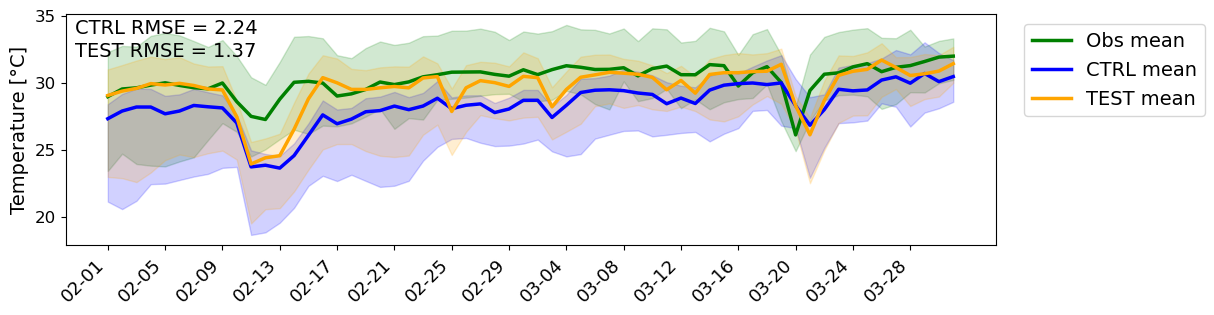

In [18]:
obs_arr  = np.array(PCD_temp_avgs["obs"])
ctrl_arr = np.array(PCD_temp_avgs["ctrl"])
test_arr = np.array(PCD_temp_avgs["test"])

obs_mean  = np.nanmean(obs_arr, axis=0)
ctrl_mean = np.nanmean(ctrl_arr, axis=0)
test_mean = np.nanmean(test_arr, axis=0)

obs_min,  obs_max  = np.nanmin(obs_arr, axis=0),  np.nanmax(obs_arr, axis=0)
ctrl_min, ctrl_max = np.nanmin(ctrl_arr, axis=0), np.nanmax(ctrl_arr, axis=0)
test_min, test_max = np.nanmin(test_arr, axis=0), np.nanmax(test_arr, axis=0)

dates = df_cmp["date"].values
date_labels = [pd.Timestamp(d).strftime("%m-%d") for d in dates]

fig, ax = plt.subplots(figsize=(12, 3))

ax.fill_between(dates, obs_min, obs_max, color="green", alpha=0.18)
ax.fill_between(dates, ctrl_min, ctrl_max, color="blue", alpha=0.18)
ax.fill_between(dates, test_min, test_max, color="orange", alpha=0.18)

ax.plot(dates, obs_mean,  color="green",  lw=2.5, label="Obs mean")
ax.plot(dates, ctrl_mean, color="blue",   lw=2.5, label="CTRL mean")
ax.plot(dates, test_mean, color="orange", lw=2.5, label="TEST mean")

rmse_ctrl = np.sqrt(np.nanmean((ctrl_mean - obs_mean) ** 2))
rmse_test = np.sqrt(np.nanmean((test_mean - obs_mean) ** 2))

ax.text(0.01, 0.98, f"CTRL RMSE = {rmse_ctrl:.2f}",
        transform=ax.transAxes, ha="left", va="top", fontsize=14)

ax.text(0.01, 0.88, f"TEST RMSE = {rmse_test:.2f}",
        transform=ax.transAxes, ha="left", va="top", fontsize=14)

tick_dates = dates[::4]
tick_labels = [pd.Timestamp(d).strftime("%m-%d") for d in tick_dates]

ax.set_xticks(tick_dates)
ax.set_xticklabels(tick_labels, rotation=45, ha="right",fontsize=13)
ax.set_ylabel('Temperature [°C]',fontsize=14)
ax.tick_params(axis="y", labelsize=12)

ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), fontsize=14, frameon=True)
plt.show()
fig.savefig(PLOT_PATH+'JGR_Fig2a_Thailand_stations_daily_T_validation_lines.png', dpi=300, bbox_inches='tight')

### RH

In [19]:
station_type='PCD'
var='RH2M'
obs_csv = TH_METEO_OBS[(station_type, var)]
obs_df = pd.read_csv(obs_csv, parse_dates=["date"])
mask = (obs_df["date"] >= DATE_START) & (obs_df["date"] <= DATE_END)
obs_sub = obs_df.loc[mask].copy()
prefix  = OBS_PREFIX[var][station_type]
mod_var = MOD_VAR_TH[var]
offset  = -273.15 if var == "TSA" else 0.0
site_cols = [c for c in obs_sub.columns if c.startswith(prefix)]
site_cols = [c for c in site_cols if c.replace(prefix, "") in TH_METEO_URBAN_IDS[station_type]]

PCD_temp_avgs={
    'obs':[],
    'ctrl':[],
    'test':[]
}
for col in site_cols:
    site_id  = col.replace(prefix, "")
    base     = TH_METEO + f"{station_type}_stations/{site_id}_"
    test_csv = base + "urban_mod_TRHQPRCPWIND_daily.csv"
    ctrl_csv = base + "ctrl_mod_TRHQPRCPWIND_daily.csv"

    obs_ts = obs_sub[["date", col]].rename(columns={col: "obs"})
    obs_ts["obs"] = pd.to_numeric(obs_ts["obs"], errors="coerce").replace(0.0, np.nan)
    test_df = pd.read_csv(test_csv)
    test_df["Time_UTC"] = pd.to_datetime(test_df["Time_UTC"]).dt.floor("D")
    test_ts = test_df[["Time_UTC", mod_var]].rename(
        columns={"Time_UTC": "date", mod_var: "test"})
    test_ts["test"] = test_ts["test"] + offset
    ctrl_df = pd.read_csv(ctrl_csv)
    ctrl_df["Time_UTC"] = pd.to_datetime(ctrl_df["Time_UTC"]).dt.floor("D")
    ctrl_ts = ctrl_df[["Time_UTC", mod_var]].rename(
        columns={"Time_UTC": "date", mod_var: "ctrl"})
    ctrl_ts["ctrl"] = ctrl_ts["ctrl"] + offset
    df_cmp = pd.concat([
        obs_ts.set_index("date"),
        test_ts.set_index("date"),
        ctrl_ts.set_index("date"),
    ], axis=1, join="inner").reset_index().dropna(how="all")
    PCD_temp_avgs['obs'].append(df_cmp['obs'].values)
    PCD_temp_avgs['ctrl'].append(df_cmp['ctrl'].values)
    PCD_temp_avgs['test'].append(df_cmp['test'].values)

In [20]:
PCD_temp_avg_obs=np.mean(PCD_temp_avgs['obs'], axis=0).tolist()
PCD_temp_avg_ctrl=np.mean(PCD_temp_avgs['ctrl'], axis=0).tolist()
PCD_temp_avg_test=np.mean(PCD_temp_avgs['test'], axis=0).tolist()

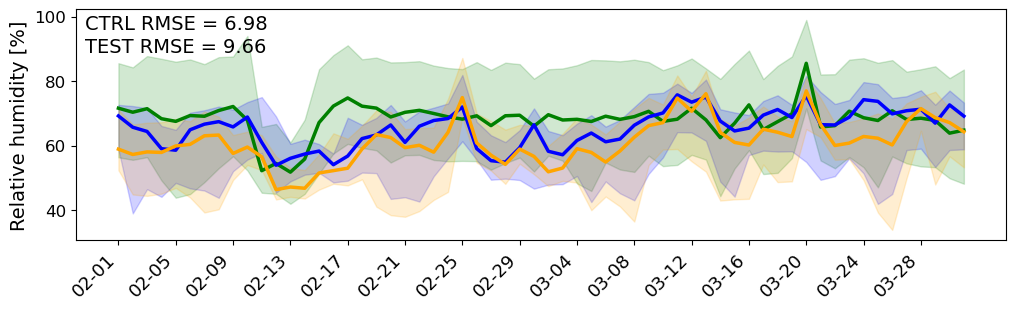

In [21]:
obs_arr  = np.array(PCD_temp_avgs["obs"])
ctrl_arr = np.array(PCD_temp_avgs["ctrl"])
test_arr = np.array(PCD_temp_avgs["test"])

obs_mean  = np.nanmean(obs_arr, axis=0)
ctrl_mean = np.nanmean(ctrl_arr, axis=0)
test_mean = np.nanmean(test_arr, axis=0)

obs_min,  obs_max  = np.nanmin(obs_arr, axis=0),  np.nanmax(obs_arr, axis=0)
ctrl_min, ctrl_max = np.nanmin(ctrl_arr, axis=0), np.nanmax(ctrl_arr, axis=0)
test_min, test_max = np.nanmin(test_arr, axis=0), np.nanmax(test_arr, axis=0)

dates = df_cmp["date"].values
date_labels = [pd.Timestamp(d).strftime("%m-%d") for d in dates]

fig, ax = plt.subplots(figsize=(12, 3))

ax.fill_between(dates, obs_min, obs_max, color="green", alpha=0.18)
ax.fill_between(dates, ctrl_min, ctrl_max, color="blue", alpha=0.18)
ax.fill_between(dates, test_min, test_max, color="orange", alpha=0.18)

ax.plot(dates, obs_mean,  color="green",  lw=2.5, label="Obs mean")
ax.plot(dates, ctrl_mean, color="blue",   lw=2.5, label="CTRL mean")
ax.plot(dates, test_mean, color="orange", lw=2.5, label="TEST mean")

rmse_ctrl = np.sqrt(np.nanmean((ctrl_mean - obs_mean) ** 2))
rmse_test = np.sqrt(np.nanmean((test_mean - obs_mean) ** 2))

ax.text(0.01, 0.98, f"CTRL RMSE = {rmse_ctrl:.2f}",
        transform=ax.transAxes, ha="left", va="top", fontsize=14)

ax.text(0.01, 0.88, f"TEST RMSE = {rmse_test:.2f}",
        transform=ax.transAxes, ha="left", va="top", fontsize=14)

tick_dates = dates[::4]
tick_labels = [pd.Timestamp(d).strftime("%m-%d") for d in tick_dates]

ax.set_xticks(tick_dates)
ax.set_xticklabels(tick_labels, rotation=45, ha="right",fontsize=13)
ax.set_ylabel('Relative humidity [%]',fontsize=14)
ax.tick_params(axis="y", labelsize=12)

#ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), fontsize=14, frameon=True)
plt.show()
fig.savefig(PLOT_PATH+'JGR_Fig2a_Thailand_stations_daily_RH_validation_lines.png', dpi=300, bbox_inches='tight')

### Wind speed

In [22]:
station_type='PCD'
var='wind_speed'
obs_csv = TH_METEO_OBS[(station_type, var)]
obs_df = pd.read_csv(obs_csv, parse_dates=["date"])
mask = (obs_df["date"] >= DATE_START) & (obs_df["date"] <= DATE_END)
obs_sub = obs_df.loc[mask].copy()
prefix  = OBS_PREFIX[var][station_type]
mod_var = MOD_VAR_TH[var]
offset  = -273.15 if var == "TSA" else 0.0
site_cols = [c for c in obs_sub.columns if c.startswith(prefix)]
site_cols = [c for c in site_cols if c.replace(prefix, "") in TH_METEO_URBAN_IDS[station_type]]

PCD_temp_avgs={
    'obs':[],
    'ctrl':[],
    'test':[]
}
for col in site_cols:
    site_id  = col.replace(prefix, "")
    base     = TH_METEO + f"{station_type}_stations/{site_id}_"
    test_csv = base + "urban_mod_TRHQPRCPWIND_daily.csv"
    ctrl_csv = base + "ctrl_mod_TRHQPRCPWIND_daily.csv"

    obs_ts = obs_sub[["date", col]].rename(columns={col: "obs"})
    obs_ts["obs"] = pd.to_numeric(obs_ts["obs"], errors="coerce").replace(0.0, np.nan)
    test_df = pd.read_csv(test_csv)
    test_df["Time_UTC"] = pd.to_datetime(test_df["Time_UTC"]).dt.floor("D")
    test_ts = test_df[["Time_UTC", mod_var]].rename(
        columns={"Time_UTC": "date", mod_var: "test"})
    test_ts["test"] = test_ts["test"] + offset
    ctrl_df = pd.read_csv(ctrl_csv)
    ctrl_df["Time_UTC"] = pd.to_datetime(ctrl_df["Time_UTC"]).dt.floor("D")
    ctrl_ts = ctrl_df[["Time_UTC", mod_var]].rename(
        columns={"Time_UTC": "date", mod_var: "ctrl"})
    ctrl_ts["ctrl"] = ctrl_ts["ctrl"] + offset
    df_cmp = pd.concat([
        obs_ts.set_index("date"),
        test_ts.set_index("date"),
        ctrl_ts.set_index("date"),
    ], axis=1, join="inner").reset_index().dropna(how="all")
    PCD_temp_avgs['obs'].append(df_cmp['obs'].values)
    PCD_temp_avgs['ctrl'].append(df_cmp['ctrl'].values)
    PCD_temp_avgs['test'].append(df_cmp['test'].values)

In [23]:
PCD_temp_avg_obs=np.mean(PCD_temp_avgs['obs'], axis=0).tolist()
PCD_temp_avg_ctrl=np.mean(PCD_temp_avgs['ctrl'], axis=0).tolist()
PCD_temp_avg_test=np.mean(PCD_temp_avgs['test'], axis=0).tolist()

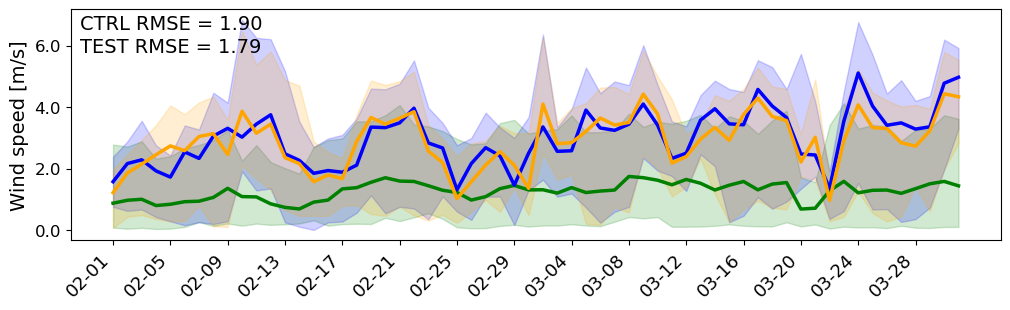

In [24]:
from matplotlib.ticker import FormatStrFormatter
obs_arr  = np.array(PCD_temp_avgs["obs"])
ctrl_arr = np.array(PCD_temp_avgs["ctrl"])
test_arr = np.array(PCD_temp_avgs["test"])

obs_mean  = np.nanmean(obs_arr, axis=0)
ctrl_mean = np.nanmean(ctrl_arr, axis=0)
test_mean = np.nanmean(test_arr, axis=0)

obs_min,  obs_max  = np.nanmin(obs_arr, axis=0),  np.nanmax(obs_arr, axis=0)
ctrl_min, ctrl_max = np.nanmin(ctrl_arr, axis=0), np.nanmax(ctrl_arr, axis=0)
test_min, test_max = np.nanmin(test_arr, axis=0), np.nanmax(test_arr, axis=0)

dates = df_cmp["date"].values
date_labels = [pd.Timestamp(d).strftime("%m-%d") for d in dates]

fig, ax = plt.subplots(figsize=(12, 3))

ax.fill_between(dates, obs_min, obs_max, color="green", alpha=0.18)
ax.fill_between(dates, ctrl_min, ctrl_max, color="blue", alpha=0.18)
ax.fill_between(dates, test_min, test_max, color="orange", alpha=0.18)

ax.plot(dates, obs_mean,  color="green",  lw=2.5, label="Obs mean")
ax.plot(dates, ctrl_mean, color="blue",   lw=2.5, label="CTRL mean")
ax.plot(dates, test_mean, color="orange", lw=2.5, label="TEST mean")

rmse_ctrl = np.sqrt(np.nanmean((ctrl_mean - obs_mean) ** 2))
rmse_test = np.sqrt(np.nanmean((test_mean - obs_mean) ** 2))

ax.text(0.01, 0.98, f"CTRL RMSE = {rmse_ctrl:.2f}",
        transform=ax.transAxes, ha="left", va="top", fontsize=14)

ax.text(0.01, 0.88, f"TEST RMSE = {rmse_test:.2f}",
        transform=ax.transAxes, ha="left", va="top", fontsize=14)

tick_dates = dates[::4]
tick_labels = [pd.Timestamp(d).strftime("%m-%d") for d in tick_dates]

ax.set_xticks(tick_dates)
ax.set_xticklabels(tick_labels, rotation=45, ha="right",fontsize=13)
ax.set_ylabel('Wind speed [m/s]',fontsize=14)
ax.tick_params(axis="y", labelsize=12)
ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

plt.show()
fig.savefig(PLOT_PATH+'JGR_Fig2a_Thailand_stations_daily_WSpeed_validation_lines.png', dpi=300, bbox_inches='tight')

### Pollutant

In [25]:
def to_daily(csv_path, time_col, var_cols, min_obs=18):
    df = pd.read_csv(csv_path)
    df[time_col] = pd.to_datetime(df[time_col]).dt.floor("h")
    df = df.set_index(time_col)[var_cols]

    daily  = df.resample("D").mean()
    counts = df.resample("D").count()

    for c in var_cols:
        daily.loc[counts[c] < min_obs, c] = np.nan

    return daily
    
print("\n=== Thailand — Air Quality ===")

TH_CONC_OBS_FILES = {
    ("PCD", "PM25"): TH_CONC + "PCD_stations/ASIAAQ-TH-PCD-PM25_Ground_20231231_R1_20240531_wDate.csv",
    ("PCD", "PM25"): TH_CONC + "PCD_stations/ASIAAQ-TH-PCD-PM25_Ground_20231231_R0_20240429_wDate.csv",
    ("PCD", "O3"):   TH_CONC + "PCD_stations/ASIAAQ-TH-PCD-O3_Ground_20231231_R1_20240531_wDate.csv",
    ("PCD", "O3"):   TH_CONC + "PCD_stations/ASIAAQ-TH-PCD-O3_Ground_20231231_R0_20240429_wDate.csv",
    ("PCD", "CO"):   TH_CONC + "PCD_stations/ASIAAQ-TH-PCD-CO_Ground_20231231_R1_20240531_wDate.csv",
    ("PCD", "CO"):   TH_CONC + "PCD_stations/ASIAAQ-TH-PCD-CO_Ground_20231231_R0_20240429_wDate.csv",
    ("PCD", "NO2"):  TH_CONC + "PCD_stations/ASIAAQ-TH-PCD-NO2_Ground_20231231_R1_20240531_wDate.csv",
    ("PCD", "NO2"):  TH_CONC + "PCD_stations/ASIAAQ-TH-PCD-NO2_Ground_20231231_R0_20240429_wDate.csv",
}

TH_URBAN_IDS = {}
for (station_type, var), obs_csv in TH_CONC_OBS_FILES.items():
    if not os.path.exists(obs_csv):
        TH_URBAN_IDS[(station_type, var)] = set()
        continue
    prefix = f"{var}_"
    obs_cols = pd.read_csv(obs_csv, nrows=0).columns.tolist()
    site_ids = [c.replace(prefix, "") for c in obs_cols if c.startswith(prefix)]
    meta = pd.read_csv(TH_CONC + f"{station_type}_stations/Thailand_{station_type}_station_info_conc.csv")
    meta = meta[meta["stationID"].isin(site_ids)]
    gdf = gpd.GeoDataFrame(
        meta,
        geometry=gpd.points_from_xy(meta["longitude_east"], meta["latitude_north"]),
        crs="EPSG:4326"
    )
    urban = gpd.sjoin(gdf, gub_th, how="inner", predicate="intersects")
    TH_URBAN_IDS[(station_type, var)] = set(urban["stationID"])


=== Thailand — Air Quality ===


In [26]:
MOD_SCALE = {"PM25": 1e9, "O3": 1e9, "NO2": 1e9, "CO": 1e6}

TH_AQ_VARS   = ["PM25", "O3",   "NO2",  "CO"]
TH_AQ_LABELS = ["PM2.5","O3",   "NO2",  "CO"]

### PM2.5

In [27]:
station_type='PCD'
var='PM25'
obs_csv = TH_CONC_OBS_FILES[(station_type, var)]
obs_raw = pd.read_csv(obs_csv, parse_dates=["date"])

prefix    = f"{var}_"
site_cols = [c for c in obs_raw.columns if c.startswith(prefix)]
obs_raw   = obs_raw.set_index("date")
obs_daily = obs_raw[site_cols].resample("D").mean()
counts    = obs_raw[site_cols].resample("D").count()
for c in site_cols:
    obs_daily.loc[counts[c] < 18, c] = np.nan

mask = (obs_daily.index >= DATE_START) & (obs_daily.index < DATE_END)
obs_sub = obs_daily.loc[mask].copy()

site_cols = [c for c in obs_sub.columns if obs_sub[c].notna().any()]
site_cols = [c for c in site_cols if c.replace(prefix, "") in TH_URBAN_IDS[(station_type, var)]]
print(len(site_cols))

scale = MOD_SCALE[var]
PCD_temp_avgs={
    'obs':[],
    'ctrl':[],
    'test':[]
}
for col in site_cols:
    site_id  = col.replace(prefix, "")
    base     = TH_CONC + f"{station_type}_stations/{site_id}_"
    test_csv = base + "urban_mod_pollutant_hourly.csv"
    ctrl_csv = base + "ctrl_mod_pollutant_hourly.csv"
    obs_ts        = obs_sub[[col]].rename(columns={col: "obs"}).reset_index()
    obs_ts["date"] = pd.to_datetime(obs_ts["date"]).dt.floor("D")

    test_d = to_daily(test_csv, "Time_UTC", [var]).reset_index()
    test_d["Time_UTC"] = pd.to_datetime(test_d["Time_UTC"]).dt.floor("D")
    test_ts = test_d[["Time_UTC", var]].rename(
        columns={"Time_UTC": "date", var: "test"})
    test_ts["test"] = test_ts["test"] * scale

    ctrl_d = to_daily(ctrl_csv, "Time_UTC", [var]).reset_index()
    ctrl_d["Time_UTC"] = pd.to_datetime(ctrl_d["Time_UTC"]).dt.floor("D")
    ctrl_ts = ctrl_d[["Time_UTC", var]].rename(
        columns={"Time_UTC": "date", var: "ctrl"})
    ctrl_ts["ctrl"] = ctrl_ts["ctrl"] * scale

    df_cmp = pd.concat([
        obs_ts.set_index("date"),
        test_ts.set_index("date"),
        ctrl_ts.set_index("date"),
    ], axis=1, join="inner").reset_index().dropna(how="all")

    ov = df_cmp["obs"].to_numpy(float)
    tv = df_cmp["test"].to_numpy(float)
    cv = df_cmp["ctrl"].to_numpy(float)
    PCD_temp_avgs['obs'].append(df_cmp['obs'].values)
    PCD_temp_avgs['ctrl'].append(df_cmp['ctrl'].values)
    PCD_temp_avgs['test'].append(df_cmp['test'].values)

55


In [28]:
PCD_temp_avg_obs=np.mean(PCD_temp_avgs['obs'], axis=0).tolist()
PCD_temp_avg_ctrl=np.mean(PCD_temp_avgs['ctrl'], axis=0).tolist()
PCD_temp_avg_test=np.mean(PCD_temp_avgs['test'], axis=0).tolist()

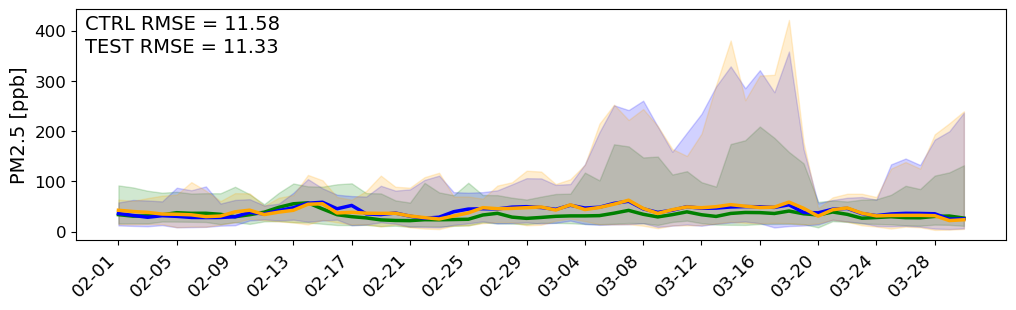

In [29]:
obs_arr  = np.array(PCD_temp_avgs["obs"])
ctrl_arr = np.array(PCD_temp_avgs["ctrl"])
test_arr = np.array(PCD_temp_avgs["test"])

obs_mean  = np.nanmean(obs_arr, axis=0)
ctrl_mean = np.nanmean(ctrl_arr, axis=0)
test_mean = np.nanmean(test_arr, axis=0)

obs_min,  obs_max  = np.nanmin(obs_arr, axis=0),  np.nanmax(obs_arr, axis=0)
ctrl_min, ctrl_max = np.nanmin(ctrl_arr, axis=0), np.nanmax(ctrl_arr, axis=0)
test_min, test_max = np.nanmin(test_arr, axis=0), np.nanmax(test_arr, axis=0)

dates = df_cmp["date"].values
date_labels = [pd.Timestamp(d).strftime("%m-%d") for d in dates]

fig, ax = plt.subplots(figsize=(12, 3))

ax.fill_between(dates, obs_min, obs_max, color="green", alpha=0.18)
ax.fill_between(dates, ctrl_min, ctrl_max, color="blue", alpha=0.18)
ax.fill_between(dates, test_min, test_max, color="orange", alpha=0.18)

ax.plot(dates, obs_mean,  color="green",  lw=2.5, label="Obs mean")
ax.plot(dates, ctrl_mean, color="blue",   lw=2.5, label="CTRL mean")
ax.plot(dates, test_mean, color="orange", lw=2.5, label="TEST mean")

rmse_ctrl = np.sqrt(np.nanmean((ctrl_mean - obs_mean) ** 2))
rmse_test = np.sqrt(np.nanmean((test_mean - obs_mean) ** 2))

ax.text(0.01, 0.98, f"CTRL RMSE = {rmse_ctrl:.2f}",
        transform=ax.transAxes, ha="left", va="top", fontsize=14)

ax.text(0.01, 0.88, f"TEST RMSE = {rmse_test:.2f}",
        transform=ax.transAxes, ha="left", va="top", fontsize=14)

tick_dates = dates[::4]
tick_labels = [pd.Timestamp(d).strftime("%m-%d") for d in tick_dates]

ax.set_xticks(tick_dates)
ax.set_xticklabels(tick_labels, rotation=45, ha="right",fontsize=13)
ax.set_ylabel('PM2.5 [ppb]',fontsize=14)
ax.tick_params(axis="y", labelsize=12)

plt.show()
fig.savefig(PLOT_PATH+'JGR_Fig2a_Thailand_stations_daily_PM25_validation_lines.png', dpi=300, bbox_inches='tight')

### O3

In [30]:
station_type='PCD'
var='O3'
obs_csv = TH_CONC_OBS_FILES[(station_type, var)]
obs_raw = pd.read_csv(obs_csv, parse_dates=["date"])

prefix    = f"{var}_"
site_cols = [c for c in obs_raw.columns if c.startswith(prefix)]
obs_raw   = obs_raw.set_index("date")
obs_daily = obs_raw[site_cols].resample("D").mean()
counts    = obs_raw[site_cols].resample("D").count()
for c in site_cols:
    obs_daily.loc[counts[c] < 18, c] = np.nan

mask = (obs_daily.index >= DATE_START) & (obs_daily.index < DATE_END)
obs_sub = obs_daily.loc[mask].copy()

site_cols = [c for c in obs_sub.columns if obs_sub[c].notna().any()]
site_cols = [c for c in site_cols if c.replace(prefix, "") in TH_URBAN_IDS[(station_type, var)]]
print(len(site_cols))

scale = MOD_SCALE[var]
PCD_temp_avgs={
    'obs':[],
    'ctrl':[],
    'test':[]
}
for col in site_cols:
    site_id  = col.replace(prefix, "")
    base     = TH_CONC + f"{station_type}_stations/{site_id}_"
    test_csv = base + "urban_mod_pollutant_hourly.csv"
    ctrl_csv = base + "ctrl_mod_pollutant_hourly.csv"
    obs_ts        = obs_sub[[col]].rename(columns={col: "obs"}).reset_index()
    obs_ts["date"] = pd.to_datetime(obs_ts["date"]).dt.floor("D")

    test_d = to_daily(test_csv, "Time_UTC", [var]).reset_index()
    test_d["Time_UTC"] = pd.to_datetime(test_d["Time_UTC"]).dt.floor("D")
    test_ts = test_d[["Time_UTC", var]].rename(
        columns={"Time_UTC": "date", var: "test"})
    test_ts["test"] = test_ts["test"] * scale

    ctrl_d = to_daily(ctrl_csv, "Time_UTC", [var]).reset_index()
    ctrl_d["Time_UTC"] = pd.to_datetime(ctrl_d["Time_UTC"]).dt.floor("D")
    ctrl_ts = ctrl_d[["Time_UTC", var]].rename(
        columns={"Time_UTC": "date", var: "ctrl"})
    ctrl_ts["ctrl"] = ctrl_ts["ctrl"] * scale

    df_cmp = pd.concat([
        obs_ts.set_index("date"),
        test_ts.set_index("date"),
        ctrl_ts.set_index("date"),
    ], axis=1, join="inner").reset_index().dropna(how="all")

    ov = df_cmp["obs"].to_numpy(float)
    tv = df_cmp["test"].to_numpy(float)
    cv = df_cmp["ctrl"].to_numpy(float)
    PCD_temp_avgs['obs'].append(df_cmp['obs'].values)
    PCD_temp_avgs['ctrl'].append(df_cmp['ctrl'].values)
    PCD_temp_avgs['test'].append(df_cmp['test'].values)

21


In [31]:
PCD_temp_avg_obs=np.mean(PCD_temp_avgs['obs'], axis=0).tolist()
PCD_temp_avg_ctrl=np.mean(PCD_temp_avgs['ctrl'], axis=0).tolist()
PCD_temp_avg_test=np.mean(PCD_temp_avgs['test'], axis=0).tolist()

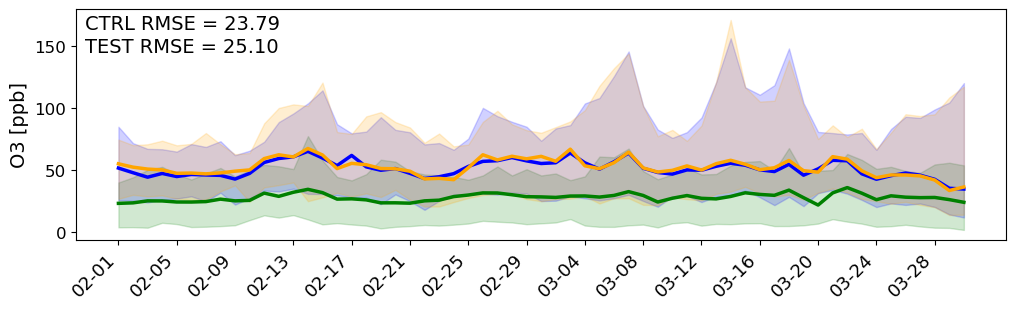

In [32]:
obs_arr  = np.array(PCD_temp_avgs["obs"])
ctrl_arr = np.array(PCD_temp_avgs["ctrl"])
test_arr = np.array(PCD_temp_avgs["test"])

obs_mean  = np.nanmean(obs_arr, axis=0)
ctrl_mean = np.nanmean(ctrl_arr, axis=0)
test_mean = np.nanmean(test_arr, axis=0)

obs_min,  obs_max  = np.nanmin(obs_arr, axis=0),  np.nanmax(obs_arr, axis=0)
ctrl_min, ctrl_max = np.nanmin(ctrl_arr, axis=0), np.nanmax(ctrl_arr, axis=0)
test_min, test_max = np.nanmin(test_arr, axis=0), np.nanmax(test_arr, axis=0)

dates = df_cmp["date"].values
date_labels = [pd.Timestamp(d).strftime("%m-%d") for d in dates]

fig, ax = plt.subplots(figsize=(12, 3))

ax.fill_between(dates, obs_min, obs_max, color="green", alpha=0.18)
ax.fill_between(dates, ctrl_min, ctrl_max, color="blue", alpha=0.18)
ax.fill_between(dates, test_min, test_max, color="orange", alpha=0.18)

ax.plot(dates, obs_mean,  color="green",  lw=2.5, label="Obs mean")
ax.plot(dates, ctrl_mean, color="blue",   lw=2.5, label="CTRL mean")
ax.plot(dates, test_mean, color="orange", lw=2.5, label="TEST mean")

rmse_ctrl = np.sqrt(np.nanmean((ctrl_mean - obs_mean) ** 2))
rmse_test = np.sqrt(np.nanmean((test_mean - obs_mean) ** 2))

ax.text(0.01, 0.98, f"CTRL RMSE = {rmse_ctrl:.2f}",
        transform=ax.transAxes, ha="left", va="top", fontsize=14)

ax.text(0.01, 0.88, f"TEST RMSE = {rmse_test:.2f}",
        transform=ax.transAxes, ha="left", va="top", fontsize=14)

tick_dates = dates[::4]
tick_labels = [pd.Timestamp(d).strftime("%m-%d") for d in tick_dates]

ax.set_xticks(tick_dates)
ax.set_xticklabels(tick_labels, rotation=45, ha="right",fontsize=13)
ax.set_ylabel('O3 [ppb]',fontsize=14)
ax.tick_params(axis="y", labelsize=12)

plt.show()
fig.savefig(PLOT_PATH+'JGR_Fig2a_Thailand_stations_daily_O3_validation_lines.png', dpi=300, bbox_inches='tight')

### NO2

In [33]:
station_type='PCD'
var='NO2'
obs_csv = TH_CONC_OBS_FILES[(station_type, var)]
obs_raw = pd.read_csv(obs_csv, parse_dates=["date"])

prefix    = f"{var}_"
site_cols = [c for c in obs_raw.columns if c.startswith(prefix)]
obs_raw   = obs_raw.set_index("date")
obs_daily = obs_raw[site_cols].resample("D").mean()
counts    = obs_raw[site_cols].resample("D").count()
for c in site_cols:
    obs_daily.loc[counts[c] < 18, c] = np.nan

mask = (obs_daily.index >= DATE_START) & (obs_daily.index < DATE_END)
obs_sub = obs_daily.loc[mask].copy()

site_cols = [c for c in obs_sub.columns if obs_sub[c].notna().any()]
site_cols = [c for c in site_cols if c.replace(prefix, "") in TH_URBAN_IDS[(station_type, var)]]
print(len(site_cols))

scale = MOD_SCALE[var]
PCD_temp_avgs={
    'obs':[],
    'ctrl':[],
    'test':[]
}
for col in site_cols:
    site_id  = col.replace(prefix, "")
    base     = TH_CONC + f"{station_type}_stations/{site_id}_"
    test_csv = base + "urban_mod_pollutant_hourly.csv"
    ctrl_csv = base + "ctrl_mod_pollutant_hourly.csv"
    obs_ts        = obs_sub[[col]].rename(columns={col: "obs"}).reset_index()
    obs_ts["date"] = pd.to_datetime(obs_ts["date"]).dt.floor("D")

    test_d = to_daily(test_csv, "Time_UTC", [var]).reset_index()
    test_d["Time_UTC"] = pd.to_datetime(test_d["Time_UTC"]).dt.floor("D")
    test_ts = test_d[["Time_UTC", var]].rename(
        columns={"Time_UTC": "date", var: "test"})
    test_ts["test"] = test_ts["test"] * scale

    ctrl_d = to_daily(ctrl_csv, "Time_UTC", [var]).reset_index()
    ctrl_d["Time_UTC"] = pd.to_datetime(ctrl_d["Time_UTC"]).dt.floor("D")
    ctrl_ts = ctrl_d[["Time_UTC", var]].rename(
        columns={"Time_UTC": "date", var: "ctrl"})
    ctrl_ts["ctrl"] = ctrl_ts["ctrl"] * scale

    df_cmp = pd.concat([
        obs_ts.set_index("date"),
        test_ts.set_index("date"),
        ctrl_ts.set_index("date"),
    ], axis=1, join="inner").reset_index().dropna(how="all")

    ov = df_cmp["obs"].to_numpy(float)
    tv = df_cmp["test"].to_numpy(float)
    cv = df_cmp["ctrl"].to_numpy(float)
    PCD_temp_avgs['obs'].append(df_cmp['obs'].values)
    PCD_temp_avgs['ctrl'].append(df_cmp['ctrl'].values)
    PCD_temp_avgs['test'].append(df_cmp['test'].values)

17


In [34]:
PCD_temp_avg_obs=np.mean(PCD_temp_avgs['obs'], axis=0).tolist()
PCD_temp_avg_ctrl=np.mean(PCD_temp_avgs['ctrl'], axis=0).tolist()
PCD_temp_avg_test=np.mean(PCD_temp_avgs['test'], axis=0).tolist()

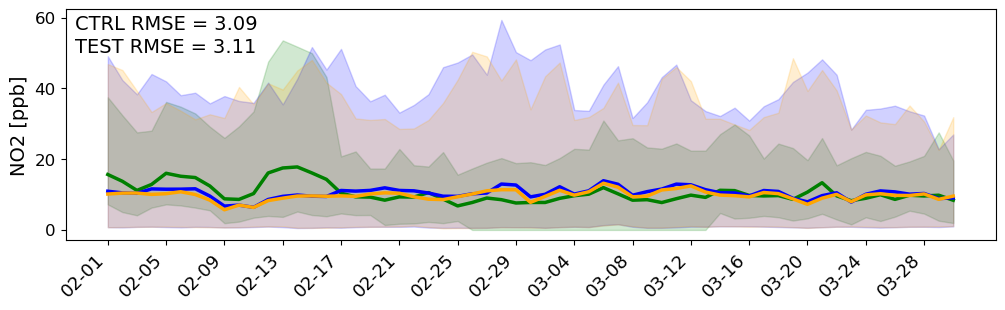

In [35]:
obs_arr  = np.array(PCD_temp_avgs["obs"])
ctrl_arr = np.array(PCD_temp_avgs["ctrl"])
test_arr = np.array(PCD_temp_avgs["test"])

obs_mean  = np.nanmean(obs_arr, axis=0)
ctrl_mean = np.nanmean(ctrl_arr, axis=0)
test_mean = np.nanmean(test_arr, axis=0)

obs_min,  obs_max  = np.nanmin(obs_arr, axis=0),  np.nanmax(obs_arr, axis=0)
ctrl_min, ctrl_max = np.nanmin(ctrl_arr, axis=0), np.nanmax(ctrl_arr, axis=0)
test_min, test_max = np.nanmin(test_arr, axis=0), np.nanmax(test_arr, axis=0)

dates = df_cmp["date"].values
date_labels = [pd.Timestamp(d).strftime("%m-%d") for d in dates]

fig, ax = plt.subplots(figsize=(12, 3))

ax.fill_between(dates, obs_min, obs_max, color="green", alpha=0.18)
ax.fill_between(dates, ctrl_min, ctrl_max, color="blue", alpha=0.18)
ax.fill_between(dates, test_min, test_max, color="orange", alpha=0.18)

ax.plot(dates, obs_mean,  color="green",  lw=2.5, label="Obs mean")
ax.plot(dates, ctrl_mean, color="blue",   lw=2.5, label="CTRL mean")
ax.plot(dates, test_mean, color="orange", lw=2.5, label="TEST mean")

rmse_ctrl = np.sqrt(np.nanmean((ctrl_mean - obs_mean) ** 2))
rmse_test = np.sqrt(np.nanmean((test_mean - obs_mean) ** 2))

ax.text(0.01, 0.98, f"CTRL RMSE = {rmse_ctrl:.2f}",
        transform=ax.transAxes, ha="left", va="top", fontsize=14)

ax.text(0.01, 0.88, f"TEST RMSE = {rmse_test:.2f}",
        transform=ax.transAxes, ha="left", va="top", fontsize=14)

tick_dates = dates[::4]
tick_labels = [pd.Timestamp(d).strftime("%m-%d") for d in tick_dates]

ax.set_xticks(tick_dates)
ax.set_xticklabels(tick_labels, rotation=45, ha="right",fontsize=13)
ax.set_ylabel('NO2 [ppb]',fontsize=14)
ax.tick_params(axis="y", labelsize=12)

plt.show()
fig.savefig(PLOT_PATH+'JGR_Fig2a_Thailand_stations_daily_NO2_validation_lines.png', dpi=300, bbox_inches='tight')

### CO

In [36]:
station_type='PCD'
var='CO'
obs_csv = TH_CONC_OBS_FILES[(station_type, var)]
obs_raw = pd.read_csv(obs_csv, parse_dates=["date"])

prefix    = f"{var}_"
site_cols = [c for c in obs_raw.columns if c.startswith(prefix)]
obs_raw   = obs_raw.set_index("date")
obs_daily = obs_raw[site_cols].resample("D").mean()
counts    = obs_raw[site_cols].resample("D").count()
for c in site_cols:
    obs_daily.loc[counts[c] < 18, c] = np.nan

mask = (obs_daily.index >= DATE_START) & (obs_daily.index < DATE_END)
obs_sub = obs_daily.loc[mask].copy()

site_cols = [c for c in obs_sub.columns if obs_sub[c].notna().any()]
site_cols = [c for c in site_cols if c.replace(prefix, "") in TH_URBAN_IDS[(station_type, var)]]
print(len(site_cols))

scale = MOD_SCALE[var]
PCD_temp_avgs={
    'obs':[],
    'ctrl':[],
    'test':[]
}
for col in site_cols:
    site_id  = col.replace(prefix, "")
    base     = TH_CONC + f"{station_type}_stations/{site_id}_"
    test_csv = base + "urban_mod_pollutant_hourly.csv"
    ctrl_csv = base + "ctrl_mod_pollutant_hourly.csv"
    obs_ts        = obs_sub[[col]].rename(columns={col: "obs"}).reset_index()
    obs_ts["date"] = pd.to_datetime(obs_ts["date"]).dt.floor("D")

    test_d = to_daily(test_csv, "Time_UTC", [var]).reset_index()
    test_d["Time_UTC"] = pd.to_datetime(test_d["Time_UTC"]).dt.floor("D")
    test_ts = test_d[["Time_UTC", var]].rename(
        columns={"Time_UTC": "date", var: "test"})
    test_ts["test"] = test_ts["test"] * scale

    ctrl_d = to_daily(ctrl_csv, "Time_UTC", [var]).reset_index()
    ctrl_d["Time_UTC"] = pd.to_datetime(ctrl_d["Time_UTC"]).dt.floor("D")
    ctrl_ts = ctrl_d[["Time_UTC", var]].rename(
        columns={"Time_UTC": "date", var: "ctrl"})
    ctrl_ts["ctrl"] = ctrl_ts["ctrl"] * scale

    df_cmp = pd.concat([
        obs_ts.set_index("date"),
        test_ts.set_index("date"),
        ctrl_ts.set_index("date"),
    ], axis=1, join="inner").reset_index().dropna(how="all")

    ov = df_cmp["obs"].to_numpy(float)
    tv = df_cmp["test"].to_numpy(float)
    cv = df_cmp["ctrl"].to_numpy(float)
    PCD_temp_avgs['obs'].append(df_cmp['obs'].values)
    PCD_temp_avgs['ctrl'].append(df_cmp['ctrl'].values)
    PCD_temp_avgs['test'].append(df_cmp['test'].values)

18


In [37]:
PCD_temp_avg_obs=np.mean(PCD_temp_avgs['obs'], axis=0).tolist()
PCD_temp_avg_ctrl=np.mean(PCD_temp_avgs['ctrl'], axis=0).tolist()
PCD_temp_avg_test=np.mean(PCD_temp_avgs['test'], axis=0).tolist()

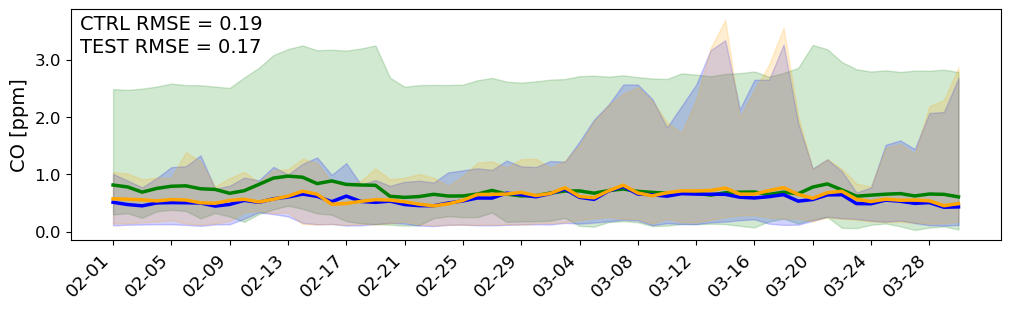

In [38]:
obs_arr  = np.array(PCD_temp_avgs["obs"])
ctrl_arr = np.array(PCD_temp_avgs["ctrl"])
test_arr = np.array(PCD_temp_avgs["test"])

obs_mean  = np.nanmean(obs_arr, axis=0)
ctrl_mean = np.nanmean(ctrl_arr, axis=0)
test_mean = np.nanmean(test_arr, axis=0)

obs_min,  obs_max  = np.nanmin(obs_arr, axis=0),  np.nanmax(obs_arr, axis=0)
ctrl_min, ctrl_max = np.nanmin(ctrl_arr, axis=0), np.nanmax(ctrl_arr, axis=0)
test_min, test_max = np.nanmin(test_arr, axis=0), np.nanmax(test_arr, axis=0)

dates = df_cmp["date"].values
date_labels = [pd.Timestamp(d).strftime("%m-%d") for d in dates]

fig, ax = plt.subplots(figsize=(12, 3))

ax.fill_between(dates, obs_min, obs_max, color="green", alpha=0.18)
ax.fill_between(dates, ctrl_min, ctrl_max, color="blue", alpha=0.18)
ax.fill_between(dates, test_min, test_max, color="orange", alpha=0.18)

ax.plot(dates, obs_mean,  color="green",  lw=2.5, label="Obs mean")
ax.plot(dates, ctrl_mean, color="blue",   lw=2.5, label="CTRL mean")
ax.plot(dates, test_mean, color="orange", lw=2.5, label="TEST mean")

rmse_ctrl = np.sqrt(np.nanmean((ctrl_mean - obs_mean) ** 2))
rmse_test = np.sqrt(np.nanmean((test_mean - obs_mean) ** 2))

ax.text(0.01, 0.98, f"CTRL RMSE = {rmse_ctrl:.2f}",
        transform=ax.transAxes, ha="left", va="top", fontsize=14)

ax.text(0.01, 0.88, f"TEST RMSE = {rmse_test:.2f}",
        transform=ax.transAxes, ha="left", va="top", fontsize=14)

tick_dates = dates[::4]
tick_labels = [pd.Timestamp(d).strftime("%m-%d") for d in tick_dates]

ax.set_xticks(tick_dates)
ax.set_xticklabels(tick_labels, rotation=45, ha="right",fontsize=13)
ax.set_ylabel('CO [ppm]',fontsize=14)
ax.tick_params(axis="y", labelsize=12)
ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

plt.show()
fig.savefig(PLOT_PATH+'JGR_Fig2a_Thailand_stations_daily_CO_validation_lines.png', dpi=300, bbox_inches='tight')

___

## Fig 2b: Performance improvement over ground sites

___

In [41]:
print("\n=== Thailand — Meteorology ===")
DATE_START, DATE_END = "2024-02-01", "2024-03-31"
TH_METEO_OBS = {
    ("BMA", "TSA"):  TH_METEO + "bma_temp_daily.csv",
    ("PCD", "TSA"):  TH_METEO + "pcd_temp_daily.csv",
    ("BMA", "RH2M"): TH_METEO + "bma_rh_daily.csv",
    ("PCD", "RH2M"): TH_METEO + "pcd_rh_daily.csv",
    ("BMA", "wind_speed"): TH_METEO + "bma_ws_daily.csv",
    ("PCD", "wind_speed"): TH_METEO + "pcd_ws_daily.csv",
    ("BMA", "wind_direction"): TH_METEO + "bma_wd_daily.csv",
    ("PCD", "wind_direction"): TH_METEO + "pcd_wd_daily.csv",
}
OBS_PREFIX = {
    "TSA":  {"BMA": "Temp_", "PCD": "TEMP_"},
    "RH2M": {"BMA": "RH_",   "PCD": "RH_"},
    "wind_speed": {"BMA": "WS_",   "PCD": "WS_"},
    "wind_direction": {"BMA": "WD_",   "PCD": "WD_"},
}
MOD_VAR_TH = {
    "TSA":  "TSA",
    "RH2M": "RH2M",
    "wind_speed": "wind_speed",
    "wind_direction": "wind_direction"
}

    
def th_meteo_cats(station_type, var):
    obs_csv = TH_METEO_OBS[(station_type, var)]
    if not os.path.exists(obs_csv):
        print(f"  WARNING: {obs_csv} not found"); return []
    obs_df = pd.read_csv(obs_csv, parse_dates=["date"])
    mask = (obs_df["date"] >= DATE_START) & (obs_df["date"] <= DATE_END)
    obs_sub = obs_df.loc[mask].copy()
    prefix  = OBS_PREFIX[var][station_type]
    mod_var = MOD_VAR_TH[var]
    offset  = -273.15 if var == "TSA" else 0.0
    site_cols = [c for c in obs_sub.columns if c.startswith(prefix)]
    site_cols = [c for c in site_cols if c.replace(prefix, "") in TH_METEO_URBAN_IDS[station_type]]
    print(len(site_cols))
    cats = {}
    for col in site_cols:
        site_id  = col.replace(prefix, "")
        base     = TH_METEO + f"{station_type}_stations/{site_id}_"
        test_csv = base + "urban_mod_TRHQPRCPWIND_daily.csv"
        ctrl_csv = base + "ctrl_mod_TRHQPRCPWIND_daily.csv"
        if not (os.path.exists(test_csv) and os.path.exists(ctrl_csv)):
            print(f"  MISSING model files for {site_id}: test={os.path.exists(test_csv)}, ctrl={os.path.exists(ctrl_csv)}")
            continue
        obs_ts = obs_sub[["date", col]].rename(columns={col: "obs"})
        obs_ts["obs"] = pd.to_numeric(obs_ts["obs"], errors="coerce").replace(0.0, np.nan)
        test_df = pd.read_csv(test_csv)
        test_df["Time_UTC"] = pd.to_datetime(test_df["Time_UTC"]).dt.floor("D")
        test_ts = test_df[["Time_UTC", mod_var]].rename(
            columns={"Time_UTC": "date", mod_var: "test"})
        test_ts["test"] = test_ts["test"] + offset
        ctrl_df = pd.read_csv(ctrl_csv)
        ctrl_df["Time_UTC"] = pd.to_datetime(ctrl_df["Time_UTC"]).dt.floor("D")
        ctrl_ts = ctrl_df[["Time_UTC", mod_var]].rename(
            columns={"Time_UTC": "date", mod_var: "ctrl"})
        ctrl_ts["ctrl"] = ctrl_ts["ctrl"] + offset
        df_cmp = pd.concat([
            obs_ts.set_index("date"),
            test_ts.set_index("date"),
            ctrl_ts.set_index("date"),
        ], axis=1, join="inner").reset_index().dropna(how="all")
        ov = df_cmp["obs"].to_numpy(float)
        tv = df_cmp["test"].to_numpy(float)
        cv = df_cmp["ctrl"].to_numpy(float)
        cats[site_id] = classify(*r2_rmse(ov, tv), *r2_rmse(ov, cv))  
    return cats


=== Thailand — Meteorology ===


19


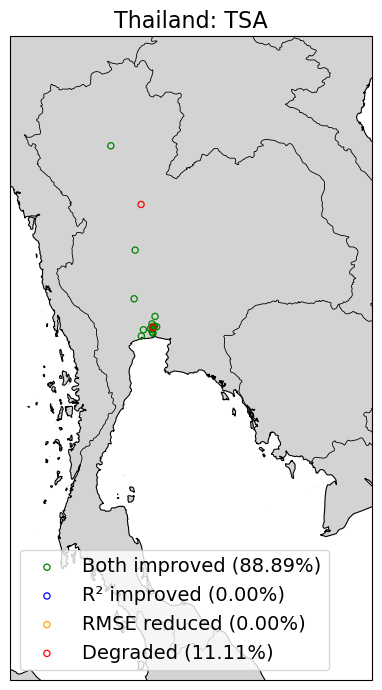

16


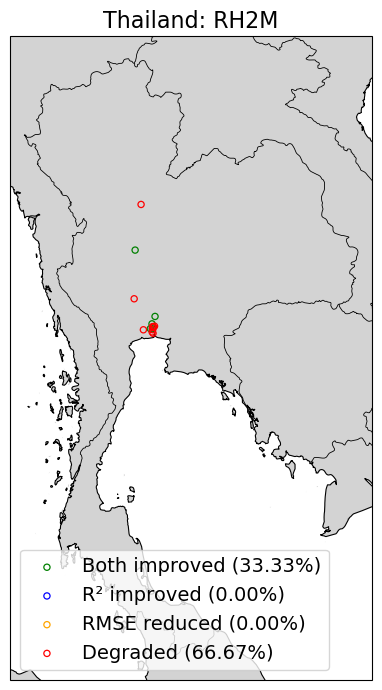

15


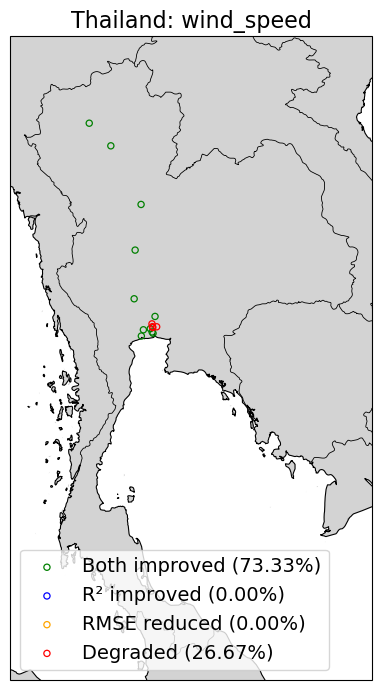

15


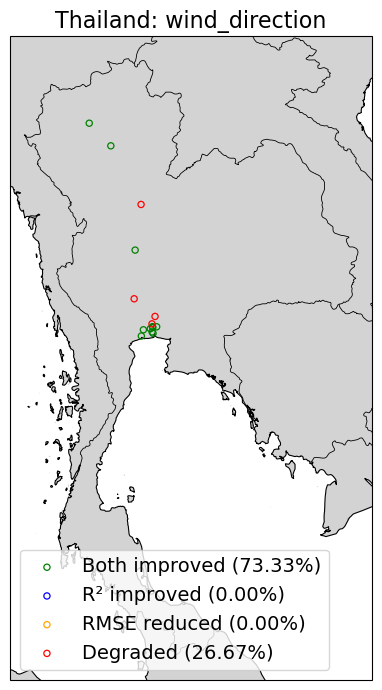

In [43]:
for var in ["TSA", "RH2M", "wind_speed", "wind_direction"]:
    pcd_cats = th_meteo_cats("PCD", var)
    plot_site_cats(pcd_cats, pcd_meteo_coord,
                   extent=EXTENT["Thailand"],
                   title=f"Thailand: {var}",
                   out_path=PLOT_PATH + f"JGR_Fig2b_sitemap_Thailand_{var}.png")

In [44]:
def to_daily(csv_path, time_col, var_cols, min_obs=18):
    df = pd.read_csv(csv_path)
    df[time_col] = pd.to_datetime(df[time_col]).dt.floor("h")
    df = df.set_index(time_col)[var_cols]

    daily  = df.resample("D").mean()
    counts = df.resample("D").count()

    for c in var_cols:
        daily.loc[counts[c] < min_obs, c] = np.nan

    return daily
    
print("\n=== Thailand — Air Quality ===")
DATE_START, DATE_END = "2024-02-01", "2024-03-31"
TH_CONC_OBS_FILES = {
    ("BMA", "PM25"): TH_CONC + "BMA_stations/ASIAAQ-TH-BMA-PM25_Ground_20231231_R1_20240531_wDate.csv",
    ("PCD", "PM25"): TH_CONC + "PCD_stations/ASIAAQ-TH-PCD-PM25_Ground_20231231_R0_20240429_wDate.csv",
    ("BMA", "O3"):   TH_CONC + "BMA_stations/ASIAAQ-TH-BMA-O3_Ground_20231231_R1_20240531_wDate.csv",
    ("PCD", "O3"):   TH_CONC + "PCD_stations/ASIAAQ-TH-PCD-O3_Ground_20231231_R0_20240429_wDate.csv",
    ("BMA", "CO"):   TH_CONC + "BMA_stations/ASIAAQ-TH-BMA-CO_Ground_20231231_R1_20240531_wDate.csv",
    ("PCD", "CO"):   TH_CONC + "PCD_stations/ASIAAQ-TH-PCD-CO_Ground_20231231_R0_20240429_wDate.csv",
    ("BMA", "NO2"):  TH_CONC + "BMA_stations/ASIAAQ-TH-BMA-NO2_Ground_20231231_R1_20240531_wDate.csv",
    ("PCD", "NO2"):  TH_CONC + "PCD_stations/ASIAAQ-TH-PCD-NO2_Ground_20231231_R0_20240429_wDate.csv",
}

TH_URBAN_IDS = {}
for (station_type, var), obs_csv in TH_CONC_OBS_FILES.items():
    if not os.path.exists(obs_csv):
        TH_URBAN_IDS[(station_type, var)] = set()
        continue
    prefix = f"{var}_"
    obs_cols = pd.read_csv(obs_csv, nrows=0).columns.tolist()
    site_ids = [c.replace(prefix, "") for c in obs_cols if c.startswith(prefix)]
    meta = pd.read_csv(TH_CONC + f"{station_type}_stations/Thailand_{station_type}_station_info_conc.csv")
    meta = meta[meta["stationID"].isin(site_ids)]
    gdf = gpd.GeoDataFrame(
        meta,
        geometry=gpd.points_from_xy(meta["longitude_east"], meta["latitude_north"]),
        crs="EPSG:4326"
    )
    urban = gpd.sjoin(gdf, gub_th, how="inner", predicate="intersects")
    TH_URBAN_IDS[(station_type, var)] = set(urban["stationID"])


=== Thailand — Air Quality ===


In [45]:
len(TH_URBAN_IDS[('PCD','PM25')]),len(TH_URBAN_IDS[('PCD','O3')]),len(TH_URBAN_IDS[('PCD','NO2')]),len(TH_URBAN_IDS[('PCD','CO')])

(55, 55, 55, 55)

In [56]:
len(TH_URBAN_IDS[('BMA','PM25')])

50

In [59]:
with open(DATA_PATH+"Thailand_ground_obs_AQ_valid_urban_site_ids.json","w") as f:
    json.dump(list(TH_URBAN_IDS[('PCD','PM25')]),f)

In [60]:
with open(DATA_PATH+"Bangkok_ground_obs_AQ_valid_urban_site_ids.json","w") as f:
    json.dump(list(TH_URBAN_IDS[('BMA','PM25')]),f)

In [61]:
with open(DATA_PATH+"Thailand_ground_obs_AQ_valid_urban_site_ids.json") as f:
    TH_AQ_URBAN_IDS=json.load(f)

with open(DATA_PATH+"Bangkok_ground_obs_AQ_valid_urban_site_ids.json") as f:
    BMA_AQ_URBAN_IDS=json.load(f)

In [62]:
len(TH_AQ_URBAN_IDS)

55

In [57]:
len(TH_URBAN_IDS[('BMA','PM25')]),len(TH_URBAN_IDS[('BMA','O3')]),len(TH_URBAN_IDS[('BMA','NO2')]),len(TH_URBAN_IDS[('BMA','CO')])

(50, 6, 10, 5)

In [46]:
MOD_SCALE = {"PM25": 1e9, "O3": 1e9, "NO2": 1e9, "CO": 1e6}

TH_AQ_VARS   = ["PM25", "O3",   "NO2",  "CO"]
TH_AQ_LABELS = ["PM2.5","O3",   "NO2",  "CO"]

def th_conc_cats(station_type, var):
    obs_csv = TH_CONC_OBS_FILES[(station_type, var)]
    if not os.path.exists(obs_csv):
        print(f"  WARNING: {obs_csv} not found"); return []

    obs_raw = pd.read_csv(obs_csv, parse_dates=["date"])

    # Aggregate hourly obs to daily mean, require >= 18 obs/day
    prefix    = f"{var}_"
    site_cols = [c for c in obs_raw.columns if c.startswith(prefix)]
    obs_raw   = obs_raw.set_index("date")
    obs_daily = obs_raw[site_cols].resample("D").mean()
    counts    = obs_raw[site_cols].resample("D").count()
    for c in site_cols:
        obs_daily.loc[counts[c] < 18, c] = np.nan

    mask = (obs_daily.index >= DATE_START) & (obs_daily.index < DATE_END)
    obs_sub = obs_daily.loc[mask].copy()

    site_cols = [c for c in obs_sub.columns if obs_sub[c].notna().any()]
    site_cols = [c for c in site_cols if c.replace(prefix, "") in TH_URBAN_IDS[(station_type, var)]]
    print(len(site_cols))
    
    scale = MOD_SCALE[var]
    cats  = {}
    for col in site_cols:
        site_id  = col.replace(prefix, "")
        base     = TH_CONC + f"{station_type}_stations/{site_id}_"
        test_csv = base + "urban_mod_pollutant_hourly.csv"
        ctrl_csv = base + "ctrl_mod_pollutant_hourly.csv"
        if not (os.path.exists(test_csv) and os.path.exists(ctrl_csv)):
            continue

        obs_ts        = obs_sub[[col]].rename(columns={col: "obs"}).reset_index()
        obs_ts["date"] = pd.to_datetime(obs_ts["date"]).dt.floor("D")

        test_d = to_daily(test_csv, "Time_UTC", [var]).reset_index()
        test_d["Time_UTC"] = pd.to_datetime(test_d["Time_UTC"]).dt.floor("D")
        test_ts = test_d[["Time_UTC", var]].rename(
            columns={"Time_UTC": "date", var: "test"})
        test_ts["test"] = test_ts["test"] * scale

        ctrl_d = to_daily(ctrl_csv, "Time_UTC", [var]).reset_index()
        ctrl_d["Time_UTC"] = pd.to_datetime(ctrl_d["Time_UTC"]).dt.floor("D")
        ctrl_ts = ctrl_d[["Time_UTC", var]].rename(
            columns={"Time_UTC": "date", var: "ctrl"})
        ctrl_ts["ctrl"] = ctrl_ts["ctrl"] * scale

        df_cmp = pd.concat([
            obs_ts.set_index("date"),
            test_ts.set_index("date"),
            ctrl_ts.set_index("date"),
        ], axis=1, join="inner").reset_index().dropna(how="all")

        ov = df_cmp["obs"].to_numpy(float)
        tv = df_cmp["test"].to_numpy(float)
        cv = df_cmp["ctrl"].to_numpy(float)
        cats[site_id] = classify(*r2_rmse(ov, tv), *r2_rmse(ov, cv))
    return cats

55


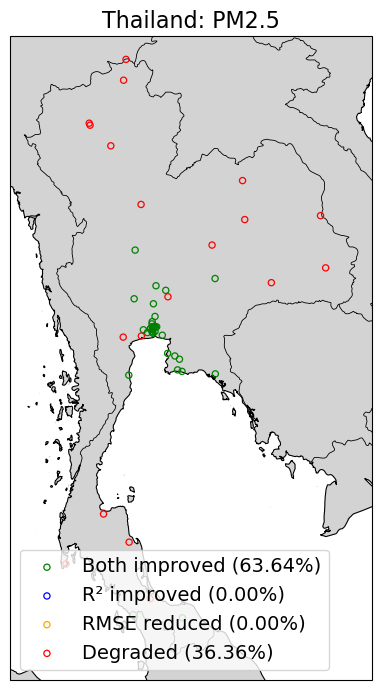

21


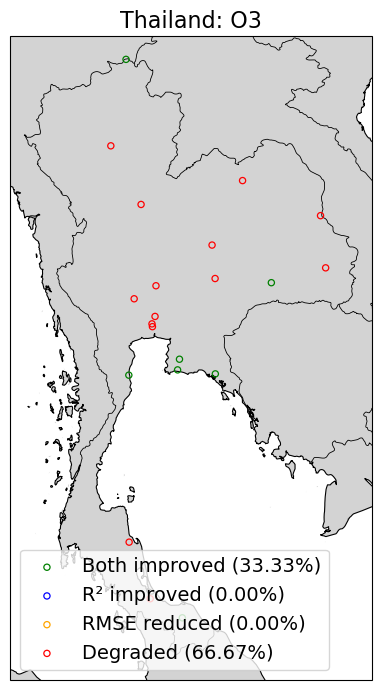

17


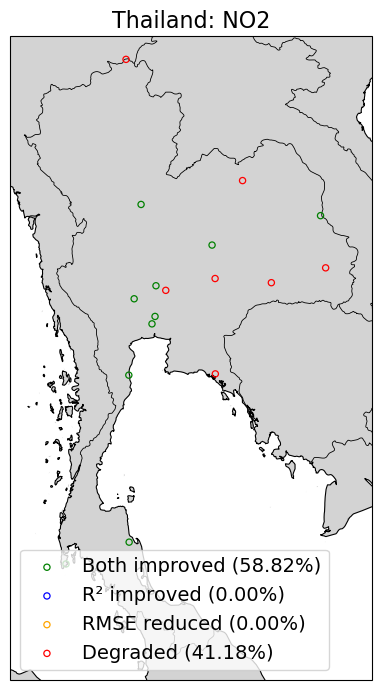

18


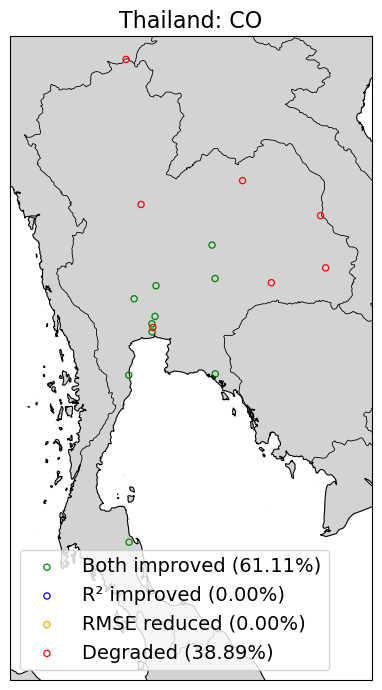

In [48]:
for var, label in zip(TH_AQ_VARS, TH_AQ_LABELS):
    pcd_cats = th_conc_cats("PCD", var)

    plot_site_cats(pcd_cats, pcd_aq_coord,
                   extent=EXTENT["Thailand"],
                   title=f"Thailand: {label}",
                   out_path=PLOT_PATH + f"JGR_Fig2b_sitemap_Thailand_{label}.png")